# MDQ DBSCAN

In [29]:
import sys
import os
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from pandas import Timedelta
from sklearn import metrics
import datetime

In [30]:
df = pd.read_csv('../csv/preprocessed_data.csv')
df_cand = pd.read_csv('../../../decoded_data/DimCandidate.csv')
df = df.set_index(['TestKey'])
df

,CandidateKey,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,...,Q2_A3,Q2_A4,Q2_A5,Q2_A6,Q3_A1,Q3_A2,Q3_A3,Q3_A4,Q3_A5,Q3_A6
TestKey,,,,,,,,,,,,,,,,,,,,,
262119,5640161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
262264,5021111,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
262265,5033381,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
262266,5104761,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
262267,5034311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512698,45644175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
512699,45644745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0
512700,45644805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0


In [31]:
df.iloc[:,1].value_counts()


Q0_A1
0.0    249774
Name: count, dtype: int64

In [32]:
df.iloc[100,2:].value_counts()

262564
0.0    15
1.0     3
4.0     2
2.0     2
6.0     1
Name: count, dtype: int64

Again, I see that the preprocessed dataframe is quite sparse, but not as sparse as the FCA answers. I start with scaling the values, add categorical values (one hot encoded, of course) and use this data to train the model

In [33]:
df_cand

,CandidateKey,ID,InstanceID,Organisation,ChosenLanguage,ChosenGender,Gender,Qualification
0,14,1,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
1,22,2,2,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Female,Gender_Female,Qualification_Unknown
2,23,2,3,4B79F6DC-F833-4721-82E3-DF6F09AE8EA2,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,NaN,Gender_Male,Qualification_Unknown
3,24,2,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
4,32,3,2,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Female,Gender_Female,Qualification_Unknown
...,...,...,...,...,...,...,...,...
2292751,50832301,5083230,1,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown
2292752,50832311,5083231,1,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown
2292753,50832321,5083232,1,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown
2292754,50832331,5083233,1,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown


In [34]:
df_cand = df_cand[['CandidateKey','Gender','Qualification']]
df_merged = df.merge(df_cand,on=['CandidateKey']).drop(columns=['CandidateKey'])
df_merged

,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,Q1_A4,...,Q2_A5,Q2_A6,Q3_A1,Q3_A2,Q3_A3,Q3_A4,Q3_A5,Q3_A6,Gender,Qualification
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Unknown
1,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Unknown,Qualification_Unknown
2,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Master
3,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Female,Qualification_Master
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Bachelor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249769,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Secondary
249770,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0,Gender_Female,Qualification_Unknown
249771,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Male,Qualification_Unknown
249772,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0,Gender_Male,Qualification_Secondary


In [35]:
df_merged = df_merged.set_index(df.index)
df_merged

,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,Q1_A4,...,Q2_A5,Q2_A6,Q3_A1,Q3_A2,Q3_A3,Q3_A4,Q3_A5,Q3_A6,Gender,Qualification
TestKey,,,,,,,,,,,,,,,,,,,,,
262119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Unknown
262264,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Unknown,Qualification_Unknown
262265,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Master
262266,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Female,Qualification_Master
262267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Bachelor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,Gender_Male,Qualification_Secondary
512699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0,Gender_Female,Qualification_Unknown
512700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,Gender_Male,Qualification_Unknown


In [36]:
cat_feat = df_merged[['Gender','Qualification']]
enc = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
enc.fit(cat_feat)
cat_feat = enc.transform(cat_feat)
cat_feat = pd.DataFrame(cat_feat,columns=enc.get_feature_names_out(), dtype='int',index=df_merged.index)
df_merged.drop(columns=['Gender','Qualification'],inplace=True)
cat_feat

,Gender_Gender_Female,Gender_Gender_Male,Gender_Gender_Unknown,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational,Qualification_nan
TestKey,,,,,,,,,,,,,
262119,0,1,0,0,0,0,0,0,0,0,1,0,0
262264,0,0,1,0,0,0,0,0,0,0,1,0,0
262265,0,1,0,0,0,1,0,0,0,0,0,0,0
262266,1,0,0,0,0,1,0,0,0,0,0,0,0
262267,0,1,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512698,0,1,0,0,0,0,0,0,0,1,0,0,0
512699,1,0,0,0,0,0,0,0,0,0,1,0,0
512700,0,1,0,0,0,0,0,0,0,0,1,0,0


In [37]:
df_merged

,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,Q1_A4,...,Q2_A3,Q2_A4,Q2_A5,Q2_A6,Q3_A1,Q3_A2,Q3_A3,Q3_A4,Q3_A5,Q3_A6
TestKey,,,,,,,,,,,,,,,,,,,,,
262119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
262264,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
262265,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
262266,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
262267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,...,0.0,2.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
512699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,6.0,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0
512700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0.0,2.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0


This is the dataframe **without** gender or qualification

<Axes: xlabel='x', ylabel='y'>

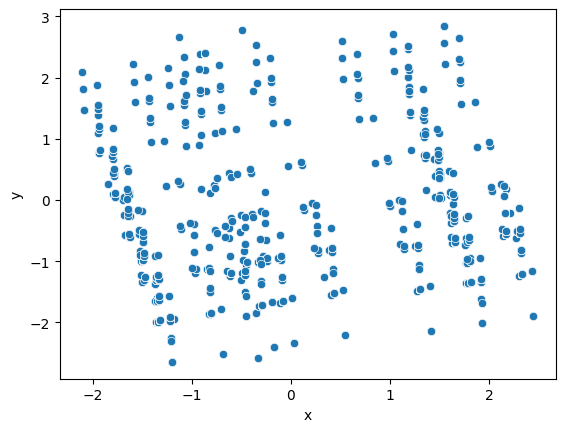

In [38]:
sc = StandardScaler()
df_scaled = pd.DataFrame(sc.fit_transform(df_merged),index=df_merged.index,columns=df_merged.columns)
df_scaled.fillna(0, inplace=True)
df_for_pca = df_scaled
pca = PCA(n_components=2)
df_pca2 = pd.DataFrame(pca.fit_transform(df_for_pca), index=df_for_pca.index,columns=['x','y'])
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)

This is **with** categorical columns

In [39]:
df_merged_with_cat = df_merged.merge(cat_feat,left_index=True,right_index=True)
df_merged_with_cat

,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,Q1_A4,...,Qualification_Qualification_Bachelor,Qualification_Qualification_MBA,Qualification_Qualification_Master,Qualification_Qualification_PHD,Qualification_Qualification_PostGraduate,Qualification_Qualification_Professional,Qualification_Qualification_Secondary,Qualification_Qualification_Unknown,Qualification_Qualification_Vocational,Qualification_nan
TestKey,,,,,,,,,,,,,,,,,,,,,
262119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0,0,0,0,0,0,0,1,0,0
262264,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0,0,0,0,0,0,0,1,0,0
262265,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0,0,1,0,0,0,0,0,0,0
262266,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,...,0,0,1,0,0,0,0,0,0,0
262267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,0,0,0,0,0,0,1,0,0,0
512699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0,0,0,0,0,0,0,1,0,0
512700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.0,...,0,0,0,0,0,0,0,1,0,0


<Axes: xlabel='x', ylabel='y'>

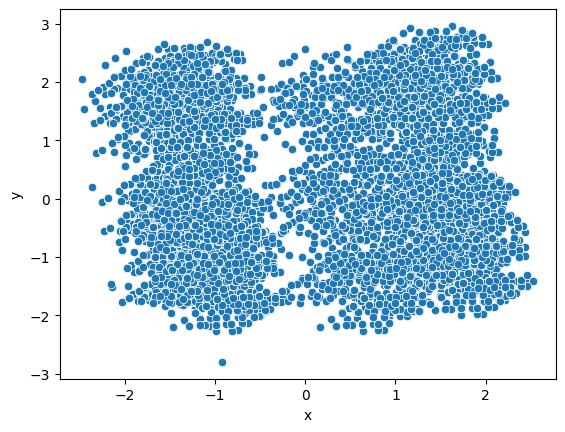

In [40]:
sc = StandardScaler()
df_scaled_with_cat = pd.DataFrame(sc.fit_transform(df_merged_with_cat),index=df_merged.index,columns=df_merged_with_cat.columns)
df_scaled_with_cat.fillna(0, inplace=True)
df_for_pca_with_cat = df_scaled_with_cat
pca = PCA(n_components=2)
df_pca2_with_cat = pd.DataFrame(pca.fit_transform(df_for_pca_with_cat), index=df_for_pca_with_cat.index,columns=['x','y'])
sns.scatterplot(df_pca2_with_cat,x=df_pca2_with_cat.x,y=df_pca2_with_cat.y)

In [41]:
# Use the unscaled merged df to perform pca and then scale the features
sc = StandardScaler()
pca10 = PCA(n_components=10)
df_pca10 = pd.DataFrame(pca10.fit_transform(df_merged_with_cat),index=df.index)
df_pca10
df_pca10_scaled = pd.DataFrame(sc.fit_transform(df_pca10),index=df.index,columns=df_pca10.columns)
df_pca10_scaled

,0,1,2,3,4,5,6,7,8,9
TestKey,,,,,,,,,,
262119,-0.858830,1.471436,-1.307931,0.549118,-0.351445,-0.271337,-0.714131,-0.807686,-1.835415,0.189014
262264,0.636213,-1.165900,-0.946702,0.057282,-0.547839,3.958204,0.180243,-0.895035,-1.127756,0.187425
262265,1.150660,0.918734,-1.214663,0.661948,-0.369244,-0.329353,-0.914726,1.538308,0.609180,1.880450
262266,0.651509,-1.192889,-0.934572,0.087431,-0.302284,-0.167386,1.241580,1.481195,-1.927513,1.988172
262267,-0.565464,1.516716,0.851397,0.739855,1.241584,-0.162993,-0.870920,1.242044,-0.425772,-1.759438
...,...,...,...,...,...,...,...,...,...,...
512698,-0.042124,1.250567,-1.405494,0.711666,2.588287,-0.083520,-0.903360,1.133547,0.251238,-1.241096
512699,-1.349590,-0.549456,-1.147484,-0.064562,-0.534735,3.897759,1.320251,-0.796563,0.059080,-0.418909
512700,-1.483730,-0.500795,1.033567,0.093395,-0.157735,-0.252121,-0.752656,-0.816046,-0.609901,0.295982


In [42]:
# sc = StandardScaler()
# pca10 = PCA(n_components=10)
# df_pca10 = pd.DataFrame(pca10.fit_transform(df_merged_with_cat),index=df.index)
# df_pca10_scaled = pd.DataFrame(sc.fit_transform(df_pca10),index=df.index,columns=df_pca10.columns)
# # best_dbscan = DBSCAN(min_samples=3,eps=0.01)
# # best_dbscan.fit(df_pca10_scaled)

Hola, now there are 2 blobs instead of a square-like shape. Let's include the gender and qualification! My first training attempt seemed to take too long, so I have to use pca. Note that for using grid search, it might suffise to use a part of the data just to get the optimal parameters. Then use this model on the full dataset.

In [43]:
def GridSearchDBScan(min_samples_values,eps_values):
  min_samples_values = min_samples_values
  eps_values = eps_values
  results = []
  for min_samples in min_samples_values:
      for eps in eps_values:
        try:   
            startTime = datetime.datetime.now()
            print(f"Trying min_samples {min_samples} and eps {eps}")
            # Create and fit DBSCAN model
            dbscan = DBSCAN(min_samples=min_samples, eps=eps)
            dbscan.fit(df_pca10_scaled.iloc[:20000])
            labels = dbscan.labels_

            if len(set(labels)) > 1:
                silhouette_avg = metrics.silhouette_score(df_pca10_scaled.iloc[:20000], labels)
            else:
                silhouette_avg = -1
            
            duration = Timedelta(datetime.datetime.now()-startTime)
            print(f"Silhouette ({min_samples,eps}): {silhouette_avg}")
            print(f"Duration: {duration}")
            results.append({
                'min_samples': min_samples,
                'eps': eps,
                'silhouette_score': silhouette_avg,
                'num_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                'num_noise': list(labels).count(-1)
            })
        except Exception as error:
           print(error)
  return results

results = GridSearchDBScan(min_samples_values=[3, 5, 10, 20, 50],eps_values=[0.01,0.05,0.5,2,5])


Trying min_samples 3 and eps 0.01
Silhouette ((3, 0.01)): 0.8284956400629322
Duration: 0 days 00:00:04.548694
Trying min_samples 3 and eps 0.05
Silhouette ((3, 0.05)): 0.8396004266930087
Duration: 0 days 00:00:04.327804
Trying min_samples 3 and eps 0.5
Silhouette ((3, 0.5)): 0.8742769714437622
Duration: 0 days 00:00:05.081323
Trying min_samples 3 and eps 2
Silhouette ((3, 2)): 0.1363502155131762
Duration: 0 days 00:00:09.296422
Trying min_samples 3 and eps 5
Silhouette ((3, 5)): -1
Duration: 0 days 00:00:15.198808
Trying min_samples 5 and eps 0.01
Silhouette ((5, 0.01)): 0.717766349239916
Duration: 0 days 00:00:04.101745
Trying min_samples 5 and eps 0.05
Silhouette ((5, 0.05)): 0.7341446157772622
Duration: 0 days 00:00:04.101216
Trying min_samples 5 and eps 0.5
Silhouette ((5, 0.5)): 0.7841475805251334
Duration: 0 days 00:00:04.984470
Trying min_samples 5 and eps 2
Silhouette ((5, 2)): 0.1364517736855384
Duration: 0 days 00:00:09.029260
Trying min_samples 5 and eps 5
Silhouette ((5, 5)

In [44]:
best_dbscan = DBSCAN(min_samples=3,eps=0.01)
best_dbscan.fit(df_pca10_scaled)
values, counts = np.unique(best_dbscan.labels_,return_counts=True)
counts[1:].sum()

247949

In [45]:
counts

array([1825,  559,   30, ...,    8,    3,    3], dtype=int64)

In [46]:
values

array([  -1,    0,    1, ..., 3679, 3680, 3681], dtype=int64)

In [47]:
labels = pd.DataFrame(best_dbscan.labels_,index=df.index, columns=['label'])
labels

,label
TestKey,
262119,0
262264,1
262265,2
262266,3
262267,4
...,...
512698,1239
512699,1110
512700,82


In [48]:
dbscan_anom = labels[labels.label==-1]

In [49]:
anomalies2d = df_pca2_with_cat.loc[dbscan_anom.index]

<Axes: xlabel='x', ylabel='y'>

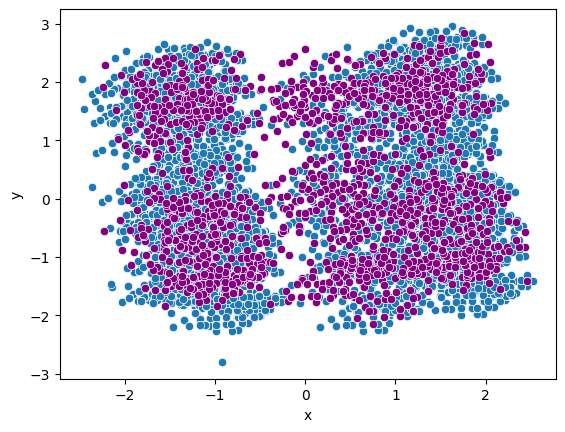

In [50]:
sns.scatterplot(df_pca2_with_cat,x=df_pca2_with_cat.x,y=df_pca2_with_cat.y)
sns.scatterplot(anomalies2d,x=anomalies2d.x,y=anomalies2d.y,color="purple")

In [51]:
labels['is_anomaly'] = labels[['label']].map(lambda label : 1 if label==-1 else 0)

In [52]:
labels.drop(columns=['label'],inplace=True)

In [53]:
os.chdir('..')
csv_path = os.path.join("csv")
os.chdir(csv_path)
labels.to_csv('dbscan_anomalies.csv')